## Tumor Subtype Classification using MOFA factors

In [1]:
import pandas as pd
import numpy as np
import mofax as mfx
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score, f1_score, average_precision_score
import h5py

Load omics data

In [2]:
mrna_data_lg2_fs = pd.read_csv("../../data/feature_selection/selected_features_mrna_data_lg2.csv", index_col = 0)
mirna_data_lg2_fs = pd.read_csv("../../data/feature_selection/selected_features_mirna_data_lg2.csv", index_col = 0)
meth_data_lg2_fs = pd.read_csv("../../data/feature_selection/selected_features_meth_data.csv", index_col = 0)

Load the saved model into mofax

In [3]:
model = mfx.mofa_model('../../data/latent/mofa_trained_lg2_fs.hdf5')

Plot Variance explained by each factor across three views

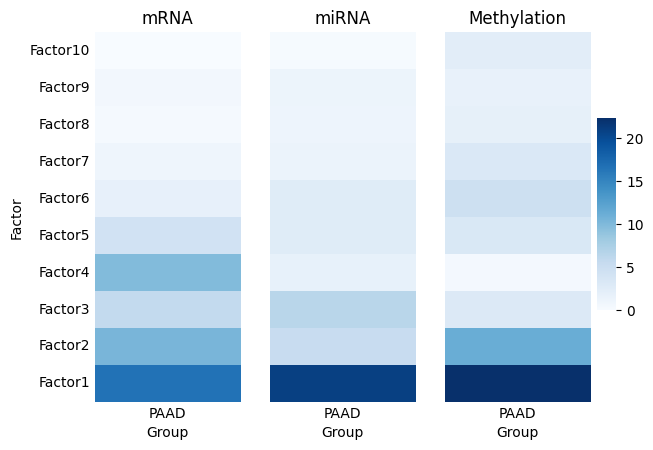

In [4]:
mfx.plot_r2(model, factors = (range(10)),cmap = 'Blues')

Extract the Latent Factors (Z matrix)

In [5]:
mofa_factors_lg2_fs = model.get_factors(df = True)

mofa_factors_lg2_fs.head()

,Factor1,Factor2,Factor3,Factor4,Factor5,Factor6,Factor7,Factor8,Factor9,Factor10
TCGA-2J-AAB1,1.806918,-1.409633,-0.103323,-0.001825,0.084401,-0.398842,0.587506,0.029626,0.008495,2.261678
TCGA-2J-AAB4,-0.143188,-0.721196,0.727170,-0.422425,-0.536559,1.052238,-1.082419,0.843612,0.170550,0.474452
TCGA-2J-AAB6,0.597470,-2.139567,0.410152,0.191220,-3.003297,-4.239297,1.135256,0.750353,0.078730,1.467823
TCGA-2J-AAB8,2.368822,2.169345,-1.682574,0.269258,-1.157539,0.605201,0.010762,0.080889,0.089455,1.053297
TCGA-2J-AAB9,-1.805625,0.647606,2.486784,-0.079220,-0.126157,0.685986,-1.245190,0.025547,0.118708,2.038217


Load clinical data

In [6]:
clinical_data = pd.read_csv('../../data/cleaned_data/clinical_cleaned.csv', index_col = 0)

Set the factors dataframe aligned with clinical dataset

In [7]:
mofa_factors_lg2_fs = mofa_factors_lg2_fs.loc[clinical_data.index]

X = Factors; y = tumor_subtype

In [8]:
y = clinical_data['tumor_subtype'].map({'other_subtype': 0, 'ductal_type': 1})

In [9]:
X = mofa_factors_lg2_fs

Stratified 5-Fold Cross Validation

In [10]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Train RF on MOFA factors

In [ ]:
def run_classification(X, y, model_name):

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    balanced_accuracy_train_scores, balanced_accuracy_test_scores = [], []
    f1_train_scores, f1_test_scores = [], []
    pr_auc_train_scores, pr_auc_test_scores = [], []

    print(f"Results for: {model_name}")

    for fold, (train_index, test_index) in enumerate(skf.split(X, y), 1):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        rf_classifier = RandomForestClassifier(
            n_estimators = 500, 
            max_depth = 5,
            min_samples_leaf = 5,
            min_samples_split = 10,
            class_weight = 'balanced',
            random_state = 42,
            n_jobs = -1
            )
        rf_classifier.fit(X_train, y_train)

        y_train_pred = rf_classifier.predict(X_train)
        y_train_prob = rf_classifier.predict_proba(X_train)[:, 1]
        y_test_pred = rf_classifier.predict(X_test)
        y_test_prob = rf_classifier.predict_proba(X_test)[:, 1]

        cm = confusion_matrix(y_test, y_test_pred)
        print(f"\nConfusion matrix - Fold {fold} - {model_name}")
        print(cm)

        print(classification_report(
            y_test,
            y_test_pred,
            target_names=["other_subtype", "ductal_type"]
        ))

        bal_acc_train = balanced_accuracy_score(y_train, y_train_pred)
        f1_train = f1_score(y_train, y_train_pred)
        pr_auc_train = average_precision_score(y_train, y_train_prob)

        bal_acc_test = balanced_accuracy_score(y_test, y_test_pred)
        f1_test = f1_score(y_test, y_test_pred)
        pr_auc_test = average_precision_score(y_test, y_test_prob)

        balanced_accuracy_train_scores.append(bal_acc_train)
        balanced_accuracy_test_scores.append(bal_acc_test)
        f1_train_scores.append(f1_train)
        f1_test_scores.append(f1_test)
        pr_auc_train_scores.append(pr_auc_train)
        pr_auc_test_scores.append(pr_auc_test)


        print(f"Fold {fold} | "
              f"Train: Bal Acc: {bal_acc_train:.3f}, F1: {f1_train:.3f}, PR AUC: {pr_auc_train:.3f} | "
              f"Test: Bal Acc: {bal_acc_test:.3f}, F1: {f1_test:.3f}, PR AUC: {pr_auc_test:.3f}")

    results = {"balanced_accuracy_train_mean": np.mean(balanced_accuracy_train_scores),
           "balanced_accuracy_test_mean": np.mean(balanced_accuracy_test_scores),
           "f1_train_mean": np.mean(f1_train_scores),
           "f1_test_mean": np.mean(f1_test_scores),
           "pr_auc_train_mean": np.mean(pr_auc_train_scores),
           "pr_auc_test_mean": np.mean(pr_auc_test_scores)}


    print("\nAverage Scores Across Folds:")
    print(f"Balanced Accuracy - Train: {results['balanced_accuracy_train_mean']:.3f}, Test: {results['balanced_accuracy_test_mean']:.3f}")
    print(f"F1 Score - Train: {results['f1_train_mean']:.3f}, Test: {results['f1_test_mean']:.3f}")
    print(f"PR AUC - Train: {results['pr_auc_train_mean']:.3f}, Test: {results['pr_auc_test_mean']:.3f}")

    return results



clinical_data = pd.read_csv('../../data/cleaned_data/clinical_cleaned.csv', index_col = 0)
y = clinical_data['tumor_subtype'].map({'other_subtype': 1, 'ductal_type': 0})


mofa_models = {
    "mofa_trained_lg2": "../../data/latent/mofa_trained_lg2.hdf5",
    "mofa_trained_vsn": "../../data/latent/mofa_trained_vsn.hdf5",
    "mofa_trained_lg2_fs": "../../data/latent/mofa_trained_lg2_fs.hdf5",
    "mofa_trained_vsn_fs": "../../data/latent/mofa_trained_vsn_fs.hdf5"
}



all_results = {}

for model_name, model_path in mofa_models.items():
    X = load_mofa_factors(model_path, clinical_data.index)
    results = run_classification(X, y, model_name)
    all_results[model_name] = results

summary_df = pd.DataFrame(all_results).T
print("\nSummary of Results:")
display(summary_df)



In [11]:
balanced_accuracy_train_scores, balanced_accuracy_test_scores = [], []
f1_train_scores, f1_test_scores = [], []
pr_auc_train_scores, pr_auc_test_scores = [], []

for fold, (train_index, test_index) in enumerate(skf.split(X, y), 1):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    rf_classifier = RandomForestClassifier(n_estimators = 500, class_weight = 'balanced', random_state = 42, n_jobs = -1)
    rf_classifier.fit(X_train, y_train)

    y_train_pred = rf_classifier.predict(X_train)
    y_train_prob = rf_classifier.predict_proba(X_train)[:, 1]
    y_test_pred = rf_classifier.predict(X_test)
    y_test_prob = rf_classifier.predict_proba(X_test)[:, 1]

    bal_acc_train = balanced_accuracy_score(y_train, y_train_pred)
    f1_train = f1_score(y_train, y_train_pred)
    pr_auc_train = average_precision_score(y_train, y_train_prob)

    bal_acc_test = balanced_accuracy_score(y_test, y_test_pred)
    f1_test = f1_score(y_test, y_test_pred)
    pr_auc_test = average_precision_score(y_test, y_test_prob)

    balanced_accuracy_train_scores.append(bal_acc_train)
    balanced_accuracy_test_scores.append(bal_acc_test)
    f1_train_scores.append(f1_train)
    f1_test_scores.append(f1_test)
    pr_auc_train_scores.append(pr_auc_train)
    pr_auc_test_scores.append(pr_auc_test)


    print(f"Fold {fold} | "
          f"Train: Bal Acc: {bal_acc_train:.3f}, F1: {f1_train:.3f}, PR AUC: {pr_auc_train:.3f} | "
          f"Test: Bal Acc: {bal_acc_test:.3f}, F1: {f1_test:.3f}, PR AUC: {pr_auc_test:.3f}")

print("\nAverage Scores Across Folds:")
print(f"Balanced Accuracy - Train: {np.mean(balanced_accuracy_train_scores):.3f}, Test: {np.mean(balanced_accuracy_test_scores):.3f}")
print(f"F1 Score - Train: {np.mean(f1_train_scores):.3f}, Test: {np.mean(f1_test_scores):.3f}")
print(f"PR AUC - Train: {np.mean(pr_auc_train_scores):.3f}, Test: {np.mean(pr_auc_test_scores):.3f}")


Fold 1 | Train: Bal Acc: 1.000, F1: 1.000, PR AUC: 1.000 | Test: Bal Acc: 0.583, F1: 0.923, PR AUC: 0.951
Fold 2 | Train: Bal Acc: 1.000, F1: 1.000, PR AUC: 1.000 | Test: Bal Acc: 0.750, F1: 0.951, PR AUC: 0.895
Fold 3 | Train: Bal Acc: 1.000, F1: 1.000, PR AUC: 1.000 | Test: Bal Acc: 0.583, F1: 0.921, PR AUC: 0.870
Fold 4 | Train: Bal Acc: 1.000, F1: 1.000, PR AUC: 1.000 | Test: Bal Acc: 0.583, F1: 0.921, PR AUC: 0.924
Fold 5 | Train: Bal Acc: 1.000, F1: 1.000, PR AUC: 1.000 | Test: Bal Acc: 0.600, F1: 0.938, PR AUC: 0.899

Average Scores Across Folds:
Balanced Accuracy - Train: 1.000, Test: 0.620
F1 Score - Train: 1.000, Test: 0.931
PR AUC - Train: 1.000, Test: 0.908


Summarize importance of MOFA factors

In [13]:
feature_importances_df = pd.DataFrame(rf_classifier.feature_importances_, index = X.columns, columns = ['Importance'])
feature_importances_df = feature_importances_df.sort_values(by = 'Importance', ascending = False)
feature_importances_df.head(10)

,Importance
Factor10,0.160041
Factor1,0.157920
Factor3,0.117317
Factor2,0.105998
Factor7,0.091564
Factor9,0.086554
Factor8,0.083154
Factor5,0.071392
Factor4,0.064104
Factor6,0.061955


In [14]:
top3_factors = feature_importances_df.head(3)
top3_factors.head(3)

,Importance
Factor10,0.160041
Factor1,0.157920
Factor3,0.117317


Original Features Weights for each Factor

In [15]:
weights = model.get_weights(df = True)
weights.head()

,Factor1,Factor2,Factor3,Factor4,Factor5,Factor6,Factor7,Factor8,Factor9,Factor10
ENSG00000000003,0.151250,0.005332,0.178914,-0.458438,-0.029956,-0.017508,-0.017054,0.037156,0.005573,-0.001223
ENSG00000000419,0.059092,-0.000943,-0.113072,-0.406086,-0.004729,-0.068200,0.005171,-0.018367,0.000274,-0.000446
ENSG00000000460,0.075373,0.000031,-0.040625,-0.371070,-0.000380,-0.058854,0.005452,-0.002216,-0.001084,0.000706
ENSG00000000938,0.031589,0.351565,0.004363,-0.470607,-0.012255,0.102502,0.019865,0.033427,0.024448,-0.001951
ENSG00000000971,0.066688,0.244021,0.072192,-0.881393,-0.215276,0.170208,0.001178,-0.003538,0.227104,0.000322


Get views of each feature in weights

In [16]:
mrna_features = set(mrna_data_lg2_fs.columns)
mirna_features = set(mirna_data_lg2_fs.columns)
meth_features = set(meth_data_lg2_fs.columns)

In [17]:
def get_view(feature):
    if feature in mrna_features:
        return 'mRNA'
    elif feature in mirna_features:
        return 'miRNA'
    elif feature in meth_features:
        return 'Methylation'
    else:
        return 'Unknown'

In [18]:
weights['view'] = [get_view(f) for f in weights.index]
weights.head()

,Factor1,Factor2,Factor3,Factor4,Factor5,Factor6,Factor7,Factor8,Factor9,Factor10,view
ENSG00000000003,0.151250,0.005332,0.178914,-0.458438,-0.029956,-0.017508,-0.017054,0.037156,0.005573,-0.001223,mRNA
ENSG00000000419,0.059092,-0.000943,-0.113072,-0.406086,-0.004729,-0.068200,0.005171,-0.018367,0.000274,-0.000446,mRNA
ENSG00000000460,0.075373,0.000031,-0.040625,-0.371070,-0.000380,-0.058854,0.005452,-0.002216,-0.001084,0.000706,mRNA
ENSG00000000938,0.031589,0.351565,0.004363,-0.470607,-0.012255,0.102502,0.019865,0.033427,0.024448,-0.001951,mRNA
ENSG00000000971,0.066688,0.244021,0.072192,-0.881393,-0.215276,0.170208,0.001178,-0.003538,0.227104,0.000322,mRNA


In [19]:
weights['view'].value_counts()

view
Methylation    60869
mRNA           12819
miRNA            298
Name: count, dtype: int64

Filtered weights to only have the top3 most important factors

In [20]:
weights_top3 = weights.loc[:, ["view"] + top3_factors.index.tolist()]
weights_top3.head(3)

,view,Factor10,Factor1,Factor3
ENSG00000000003,mRNA,-0.001223,0.151250,0.178914
ENSG00000000419,mRNA,-0.000446,0.059092,-0.113072
ENSG00000000460,mRNA,0.000706,0.075373,-0.040625


### Finding candidate biomarkers

Which subtype is Factor10 higher in?

In [21]:
mean_other_subtype = X.loc[y == 0, "Factor10"].mean()
mean_ductal_type = X.loc[y == 1, "Factor10"].mean()

print(f"Mean in other_subtype: {mean_other_subtype:.3f}")
print(f"Mean in ductal_type: {mean_ductal_type:.3f}")

if mean_ductal_type > mean_other_subtype:
    print("Factor10 is higher in ductal_type")
else:
    print("Factor10 is higher in other_subtype")

Mean in other_subtype: 0.448
Mean in ductal_type: -0.088
Factor10 is higher in other_subtype


([0, 1], [Text(0, 0, 'other_subtype'), Text(1, 0, 'ductal_type')])

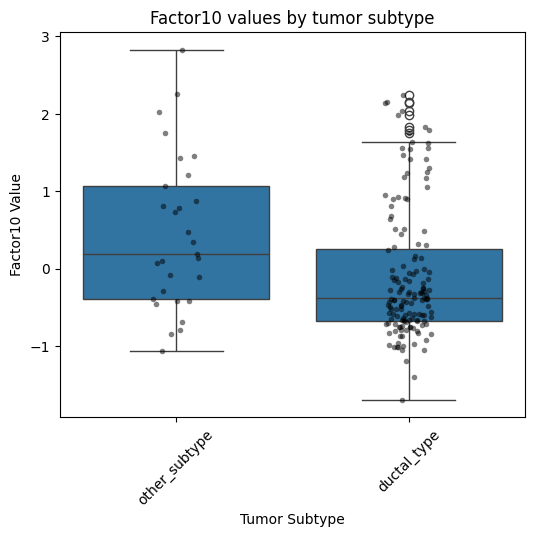

In [32]:
import matplotlib
import seaborn as sns

factor10_plot_df = pd.DataFrame({'Factor10': X['Factor10'],'tumor_subtype': clinical_data['tumor_subtype']})

plt.figure(figsize=(6, 5))
sns.boxplot(data=factor10_plot_df, x='tumor_subtype', y='Factor10')
sns.stripplot(data=factor10_plot_df, x='tumor_subtype', y='Factor10', color='black', alpha=0.5, size=4)
plt.title('Factor10 values by tumor subtype')
plt.xlabel('Tumor Subtype')
plt.ylabel('Factor10 Value')
plt.xticks(rotation=45)

Top 10 mRNA features by absolute weight for Factor10

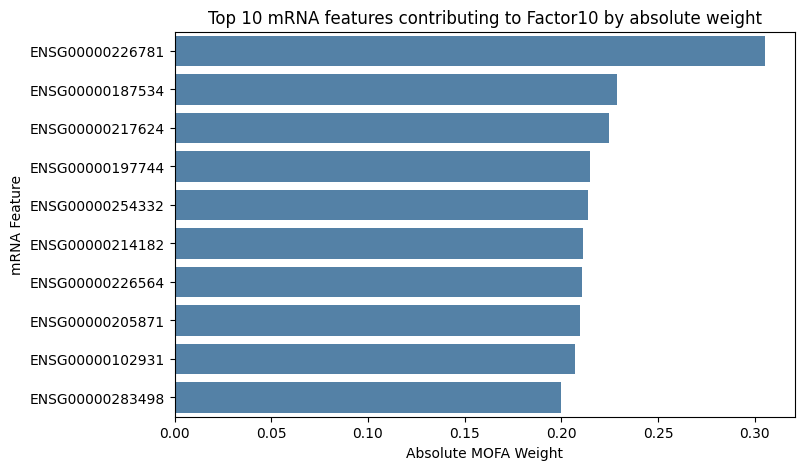

In [33]:
top10_mrna_features_f10 = weights_top3[weights_top3['view'] == 'mRNA'][['Factor10']].copy()
top10_mrna_features_f10['abs_weight'] = top10_mrna_features_f10['Factor10'].abs()
top10_mrna_features_f10 = top10_mrna_features_f10.sort_values(by = 'abs_weight', ascending = False).head(10)
top10_mrna_features_f10 = top10_mrna_features_f10.reset_index().rename(columns = {'index': 'feature'})

plt.figure(figsize=(8, 5))
sns.barplot(data = top10_mrna_features_f10, x = 'abs_weight', y = 'feature', color = 'steelblue')
plt.title('Top 10 mRNA features contributing to Factor10 by absolute weight')
plt.xlabel('Absolute MOFA Weight')
plt.ylabel('mRNA Feature')
plt.show()

Top 10 miRNA features by absolute weight for Factor10

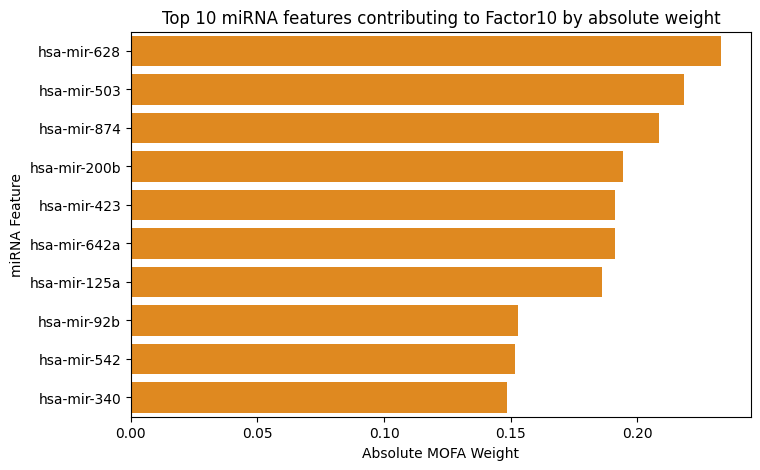

In [34]:
top10_mirna_features_f10 = weights_top3[weights_top3['view'] == 'miRNA'][['Factor10']].copy()
top10_mirna_features_f10['abs_weight'] = top10_mirna_features_f10['Factor10'].abs()
top10_mirna_features_f10 = top10_mirna_features_f10.sort_values(by = 'abs_weight', ascending = False).head(10)
top10_mirna_features_f10 = top10_mirna_features_f10.reset_index().rename(columns = {'index': 'feature'})

plt.figure(figsize=(8, 5))
sns.barplot(data = top10_mirna_features_f10, x = 'abs_weight', y = 'feature', color = 'darkorange')
plt.title('Top 10 miRNA features contributing to Factor10 by absolute weight')
plt.xlabel('Absolute MOFA Weight')
plt.ylabel('miRNA Feature')
plt.show()

Top 10 DNA methylation features by absolute weight for Factor10

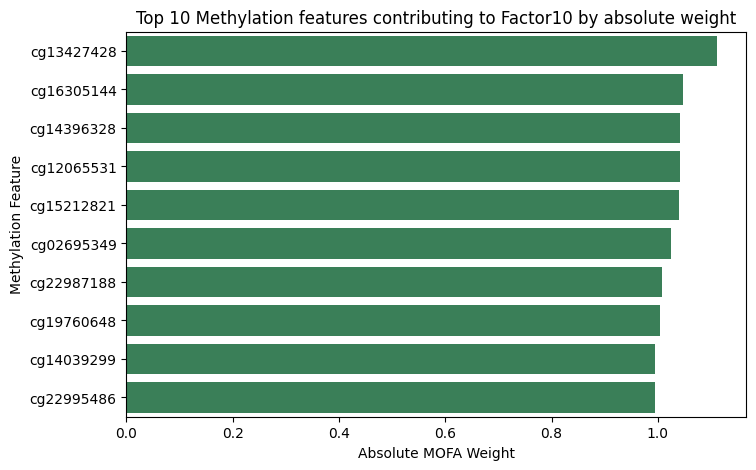

In [35]:
top10_meth_features_f10 = weights_top3[weights_top3['view'] == 'Methylation'][['Factor10']].copy()
top10_meth_features_f10['abs_weight'] = top10_meth_features_f10['Factor10'].abs()
top10_meth_features_f10 = top10_meth_features_f10.sort_values(by = 'abs_weight', ascending = False).head(10)
top10_meth_features_f10 = top10_meth_features_f10.reset_index().rename(columns = {'index': 'feature'})

plt.figure(figsize=(8, 5))
sns.barplot(data = top10_meth_features_f10, x = 'abs_weight', y = 'feature', color = 'seagreen')
plt.title('Top 10 Methylation features contributing to Factor10 by absolute weight')
plt.xlabel('Absolute MOFA Weight')
plt.ylabel('Methylation Feature')
plt.show()

Top positive and top negative features

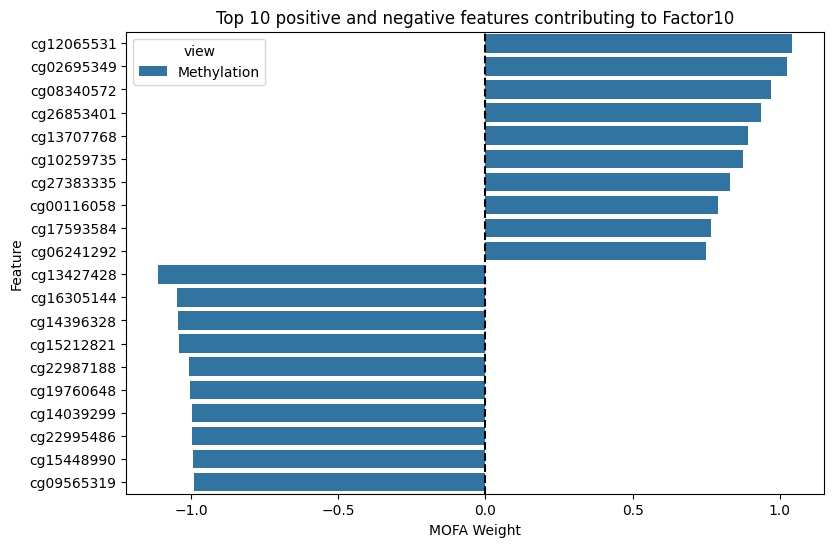

In [36]:
factor10_all = weights_top3[['view', 'Factor10']].copy()
factor10_all = factor10_all.reset_index().rename(columns = {'index': 'feature'})
factor10_all['sign'] = np.where(factor10_all['Factor10'] >= 0, 'positive', 'negative')
factor10_all['abs_weight'] = factor10_all['Factor10'].abs()

top_positive = factor10_all.sort_values('Factor10', ascending=False).head(10)
top_negative = factor10_all.sort_values('Factor10', ascending=True).head(10)

factor10_signed = pd.concat([top_positive, top_negative], axis=0)

plt.figure(figsize=(9, 6))
sns.barplot(data = factor10_signed, x = 'Factor10', y = 'feature', hue = 'view')
plt.title('Top 10 positive and negative features contributing to Factor10')
plt.xlabel('MOFA Weight')
plt.ylabel('Feature')
plt.axvline(0, color='black', linestyle='--')
plt.show()

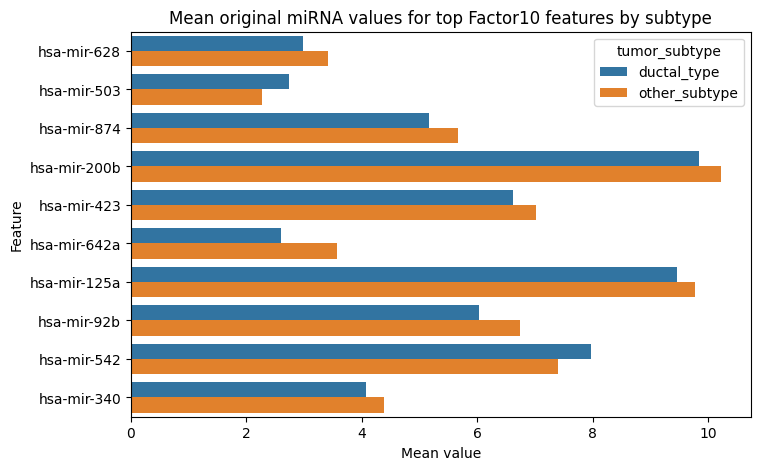

In [41]:
top_mirna_features = top10_mirna_features_f10['feature'].tolist()

mirna_check = mirna_data_lg2_fs.loc[clinical_data.index, top_mirna_features].copy()
mirna_check['tumor_subtype'] = clinical_data['tumor_subtype']

mirna_means = mirna_check.groupby('tumor_subtype').mean().T
mirna_means = mirna_means.reset_index().rename(columns={'index': 'feature'})

mirna_means_long = mirna_means.melt(id_vars='feature', var_name='tumor_subtype', value_name='mean_value')

plt.figure(figsize=(8, 5))
sns.barplot(data=mirna_means_long, x='mean_value', y='feature', hue='tumor_subtype')
plt.title('Mean original miRNA values for top Factor10 features by subtype')
plt.xlabel('Mean value')
plt.ylabel('Feature')
plt.show()


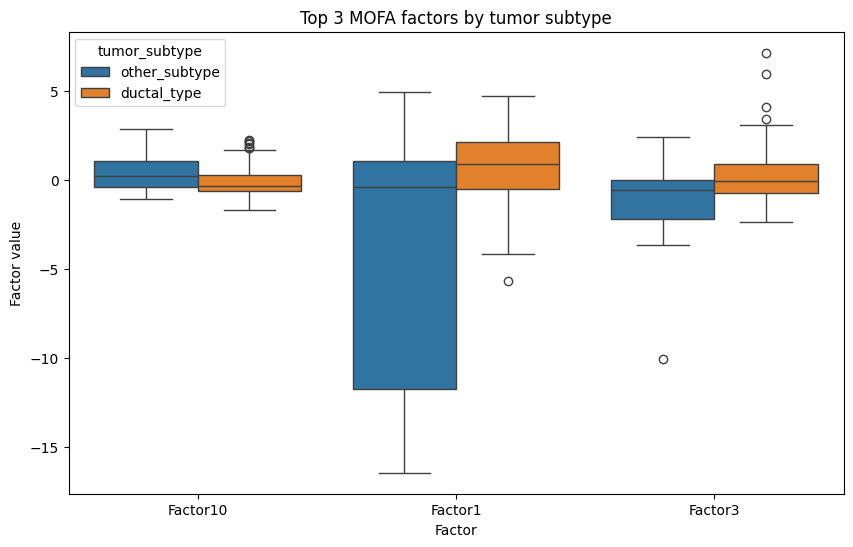

In [42]:
top3_names = top3_factors.index.tolist()

top3_plot_df = X[top3_names].copy()
top3_plot_df['tumor_subtype'] = clinical_data['tumor_subtype']

top3_long = top3_plot_df.melt(id_vars='tumor_subtype', var_name='factor', value_name='value')

plt.figure(figsize=(10, 6))
sns.boxplot(data=top3_long, x='factor', y='value', hue='tumor_subtype')
plt.title('Top 3 MOFA factors by tumor subtype')
plt.xlabel('Factor')
plt.ylabel('Factor value')
plt.show()


Do those features differ between ductal_type and other_subtype in the original data?

In [28]:
mrna_features = top10_mrna_features_f10.index.tolist()

mrna_check = mrna_data_lg2_fs.loc[clinical_data.index, mrna_features].copy()
mrna_check['tumor_subtype'] = clinical_data['tumor_subtype']

mrna_check.groupby('tumor_subtype').mean().T


tumor_subtype,ductal_type,other_subtype
ENSG00000226781,3.083440,3.375678
ENSG00000187534,3.507025,3.207014
ENSG00000217624,1.808789,1.491030
ENSG00000197744,3.057961,2.712954
ENSG00000254332,2.216411,1.721804
ENSG00000214182,2.862855,2.530020
ENSG00000226564,3.480318,3.108766
ENSG00000205871,1.841581,2.078993
ENSG00000102931,0.636833,0.883658
ENSG00000283498,6.736728,5.980195


In [29]:
mirna_features = top10_mirna_features_f10.index.tolist()

mirna_check = mirna_data_lg2_fs.loc[clinical_data.index, mirna_features].copy()
mirna_check['tumor_subtype'] = clinical_data['tumor_subtype']

mirna_check.groupby('tumor_subtype').mean().T


tumor_subtype,ductal_type,other_subtype
hsa-mir-628,2.980544,3.418183
hsa-mir-503,2.735108,2.264106
hsa-mir-874,5.157952,5.665206
hsa-mir-200b,9.834069,10.225150
hsa-mir-423,6.622348,7.022142
hsa-mir-642a,2.602511,3.560867
hsa-mir-125a,9.459853,9.775776
hsa-mir-92b,6.029366,6.737400
hsa-mir-542,7.959885,7.399111
hsa-mir-340,4.076517,4.390035


In [30]:
meth_features = top10_meth_features_f10.index.tolist()

meth_check = meth_data_lg2_fs.loc[clinical_data.index, meth_features].copy()
meth_check['tumor_subtype'] = clinical_data['tumor_subtype']

meth_check.groupby('tumor_subtype').mean().T


tumor_subtype,ductal_type,other_subtype
cg13427428,3.446485,2.847252
cg16305144,3.281596,2.633951
cg14396328,2.603761,1.350647
cg12065531,-4.480315,-3.902526
cg15212821,3.203972,2.420050
cg02695349,3.092339,3.806568
cg22987188,3.238736,2.676251
cg19760648,3.659162,3.253754
cg14039299,3.406431,2.888581
cg22995486,3.278391,2.863721


Train SVM on MOFA factors

In [46]:
balanced_accuracy_train_scores, balanced_accuracy_test_scores = [], []
f1_train_scores, f1_test_scores = [], []
pr_auc_train_scores, pr_auc_test_scores = [], []

for fold, (train_index, test_index) in enumerate(skf.split(X, y), 1):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    classifier = SVC(kernel = 'rbf', class_weight = 'balanced', probability = True, random_state = 42)
    classifier.fit(X_train, y_train)

    y_train_pred = classifier.predict(X_train)
    y_train_prob = classifier.predict_proba(X_train)[:, 1]

    y_test_pred = classifier.predict(X_test)
    y_test_prob = classifier.predict_proba(X_test)[:, 1]

    bal_acc_train = balanced_accuracy_score(y_train, y_train_pred)
    f1_train = f1_score(y_train, y_train_pred)
    pr_auc_train = average_precision_score(y_train, y_train_prob)

    bal_acc_test = balanced_accuracy_score(y_test, y_test_pred)
    f1_test = f1_score(y_test, y_test_pred)
    pr_auc_test = average_precision_score(y_test, y_test_prob)

    balanced_accuracy_train_scores.append(bal_acc_train)
    balanced_accuracy_test_scores.append(bal_acc_test)
    f1_train_scores.append(f1_train)
    f1_test_scores.append(f1_test)
    pr_auc_train_scores.append(pr_auc_train)
    pr_auc_test_scores.append(pr_auc_test)


    print(f"Fold {fold} | "
          f"Train: Bal Acc: {bal_acc_train:.3f}, F1: {f1_train:.3f}, PR AUC: {pr_auc_train:.3f} | "
          f"Test: Bal Acc: {bal_acc_test:.3f}, F1: {f1_test:.3f}, PR AUC: {pr_auc_test:.3f}")

print("\nAverage Scores Across Folds:")
print(f"Balanced Accuracy - Train: {np.mean(balanced_accuracy_train_scores):.3f}, Test: {np.mean(balanced_accuracy_test_scores):.3f}")
print(f"F1 Score - Train: {np.mean(f1_train_scores):.3f}, Test: {np.mean(f1_test_scores):.3f}")
print(f"PR AUC - Train: {np.mean(pr_auc_train_scores):.3f}, Test: {np.mean(pr_auc_test_scores):.3f}")


Fold 1 | Train: Bal Acc: 0.757, F1: 0.933, PR AUC: 0.969 | Test: Bal Acc: 0.533, F1: 0.871, PR AUC: 0.959
Fold 2 | Train: Bal Acc: 0.801, F1: 0.922, PR AUC: 0.978 | Test: Bal Acc: 0.799, F1: 0.931, PR AUC: 0.884
Fold 3 | Train: Bal Acc: 0.805, F1: 0.927, PR AUC: 0.980 | Test: Bal Acc: 0.647, F1: 0.836, PR AUC: 0.869
Fold 4 | Train: Bal Acc: 0.739, F1: 0.952, PR AUC: 0.973 | Test: Bal Acc: 0.583, F1: 0.921, PR AUC: 0.923
Fold 5 | Train: Bal Acc: 0.712, F1: 0.930, PR AUC: 0.979 | Test: Bal Acc: 0.767, F1: 0.933, PR AUC: 0.903

Average Scores Across Folds:
Balanced Accuracy - Train: 0.763, Test: 0.666
F1 Score - Train: 0.933, Test: 0.898
PR AUC - Train: 0.976, Test: 0.907
